In [76]:
#pip install xgboost

In [77]:
# =========================================================
# TELECOM CUSTOMER CHURN PREDICTION
# MODEL TRAINING
# =========================================================

# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [78]:
# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [79]:
# =========================================================
# DATA CLEANING
# =========================================================

# Drop customerID column
df.drop('customerID', axis=1, inplace=True)

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Check missing values
print(df.isnull().sum())

# Fill missing values with median
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

# Verify no missing values
print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())

print("\nData Cleaning Completed")

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Missing Values After Cleaning:

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data Cleaning Completed


In [80]:
# =========================================================
# ENCODE CATEGORICAL VARIABLES
# =========================================================

le = LabelEncoder()

categorical_columns = df.select_dtypes(
    include=['object']
).columns

for col in categorical_columns:
    
    df[col] = le.fit_transform(df[col])

print("Categorical Encoding Completed")

Categorical Encoding Completed


In [81]:
# =========================================================
# FEATURE TARGET SPLIT
# =========================================================

X = df.drop('Churn', axis=1)

y = df['Churn']

print("Feature Target Split Completed")

Feature Target Split Completed


In [82]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Test Split Completed")

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

Train Test Split Completed
X_train Shape: (5634, 19)
X_test Shape: (1409, 19)


In [83]:
#pip install imbalanced-learn

In [84]:
from imblearn.over_sampling import SMOTE

In [85]:
# =========================================================
# HANDLE CLASS IMBALANCE USING SMOTE
# =========================================================

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

print("SMOTE Applied Successfully")

SMOTE Applied Successfully


In [86]:
# =========================================================
# FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [87]:
# =========================================================
# LOGISTIC REGRESSION
# =========================================================

lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained")

Logistic Regression Model Trained


In [88]:
# Predictions

y_pred_lr = lr_model.predict(X_test_scaled)

# Accuracy

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7508871540099361


In [89]:
# Classification Report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1035
           1       0.52      0.71      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409



In [90]:
# =========================================================
# RANDOM FOREST CLASSIFIER
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained")

Random Forest Model Trained


In [91]:
# Predictions

y_pred_rf = rf_model.predict(X_test)

# Accuracy

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.772888573456352


In [92]:
# Classification Report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1035
           1       0.56      0.69      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409



In [93]:
# =========================================================
# XGBOOST CLASSIFIER
# =========================================================

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained")

XGBoost Model Trained


In [94]:
# Predictions

y_pred_xgb = xgb_model.predict(X_test)

# Accuracy

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.7721788502484032


In [95]:
# Classification Report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1035
           1       0.57      0.61      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.77      1409



In [96]:
# =========================================================
# MODEL COMPARISON
# =========================================================

model_results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.750887
1,Random Forest,0.772889
2,XGBoost,0.772179


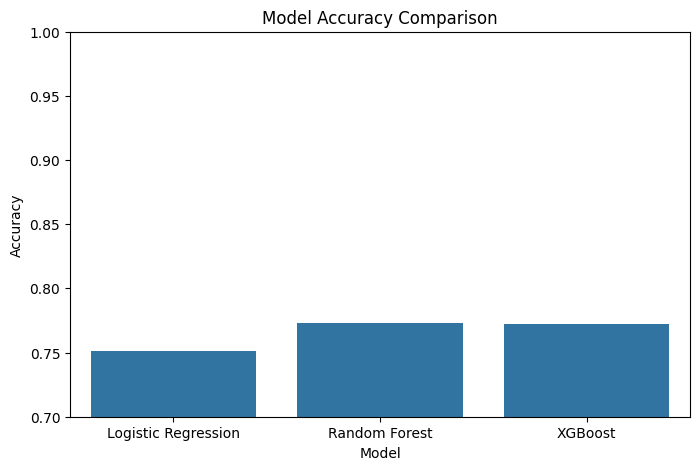

In [97]:
# =========================================================
# MODEL COMPARISON VISUALIZATION
# =========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=model_results
)

plt.title("Model Accuracy Comparison")

plt.ylim(0.7, 1.0)

plt.show()

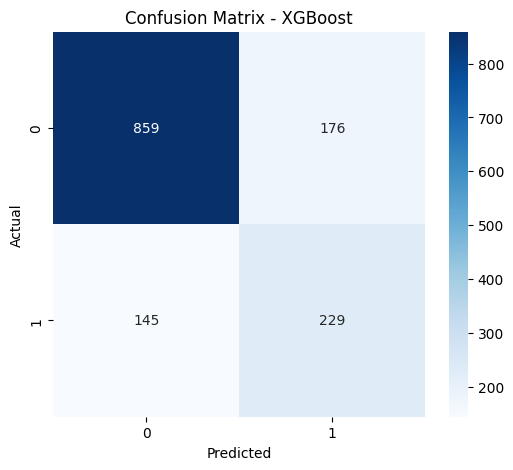

In [98]:
# =========================================================
# CONFUSION MATRIX - XGBOOST
# =========================================================

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - XGBoost")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [99]:
# =========================================================
# ROC AUC SCORE
# =========================================================

roc_score = roc_auc_score(
    y_test,
    y_pred_xgb
)

print("ROC AUC Score:", roc_score)

ROC AUC Score: 0.7211255780309489


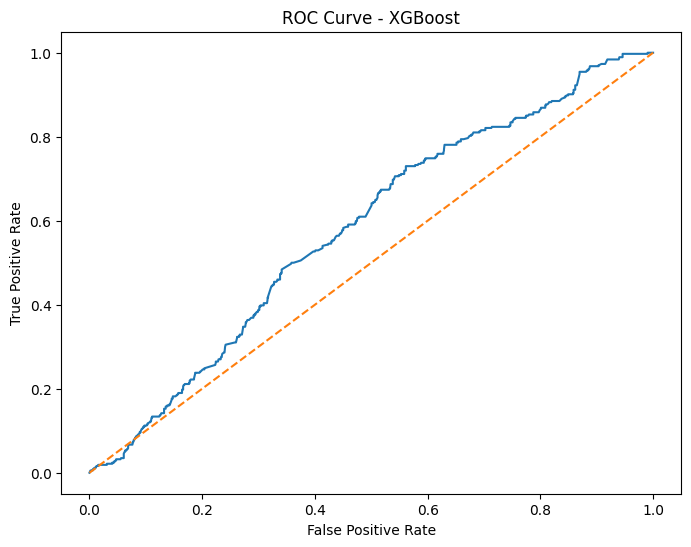

In [100]:
# =========================================================
# ROC CURVE
# =========================================================

y_prob_xgb = xgb_model.predict_proba(
    X_test_scaled
)[:,1]

fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.show()

In [101]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,Contract,0.209854
8,OnlineSecurity,0.121852
11,TechSupport,0.105527
4,tenure,0.100950
17,MonthlyCharges,0.092470
18,TotalCharges,0.084665
9,OnlineBackup,0.052169
3,Dependents,0.044733
7,InternetService,0.035160
10,DeviceProtection,0.029238


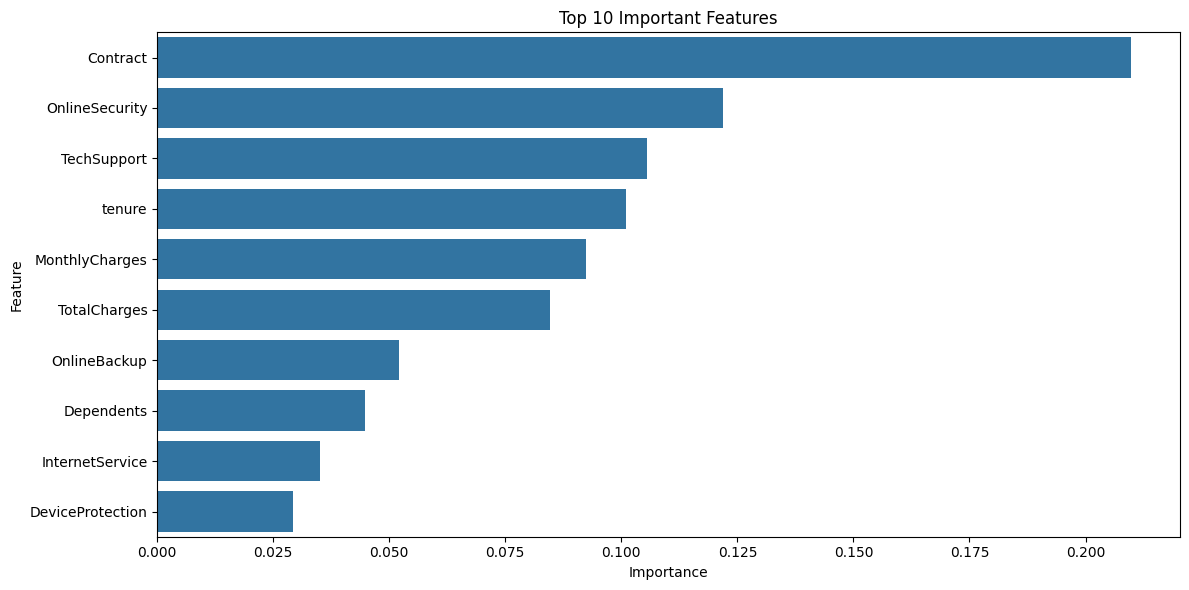

In [102]:
# =========================================================
# FEATURE IMPORTANCE VISUALIZATION
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.tight_layout()

plt.show()

In [103]:
# =========================================================
# SAVE MODEL
# =========================================================

import joblib

joblib.dump(
    rf_model,
    "../models/churn_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [104]:
# =========================================================
# FINAL INSIGHTS
# =========================================================

print("""
FINAL INSIGHTS:

1. Random Forest and XGBoost achieved the
   highest accuracy among all models.

2. Logistic Regression achieved approximately
   75% accuracy.

3. Random Forest and XGBoost achieved around
   77% accuracy.

4. Contract type is the most influential
   feature affecting customer churn.

5. Customers with weak online security and
   lack of technical support are more likely
   to churn.

6. Customers with shorter tenure and higher
   monthly charges show higher churn rates.

7. The developed model can help telecom
   companies identify customers likely
   to leave and improve retention strategies.
""")


FINAL INSIGHTS:

1. Random Forest and XGBoost achieved the
   highest accuracy among all models.

2. Logistic Regression achieved approximately
   75% accuracy.

3. Random Forest and XGBoost achieved around
   77% accuracy.

4. Contract type is the most influential
   feature affecting customer churn.

5. Customers with weak online security and
   lack of technical support are more likely
   to churn.

6. Customers with shorter tenure and higher
   monthly charges show higher churn rates.

7. The developed model can help telecom
   companies identify customers likely
   to leave and improve retention strategies.

